In [20]:
import torch
import torch.nn as nn
import pandas as pd
from copy import deepcopy as dc
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [4]:
print(f"PyTorch built with CUDA Version: {torch.version.cuda}")

PyTorch built with CUDA Version: 12.8


In [5]:
call_centers = ["A", "B", "C", "D"]
types = ["Daily", "Interval"]

dfs = pd.read_excel("data/Data for Datathon (Revised).xlsx", sheet_name=[
    f"{center} - {type}"
    for center in call_centers
    for type in types
])

In [6]:
df = dfs["A - Daily"][["Date", "CCT"]]
df

,Date,CCT
0,01/01/24 Mon,302.45
1,01/02/24 Tue,349.22
2,01/03/24 Wed,331.07
3,01/04/24 Thu,341.80
4,01/05/24 Fri,334.56
...,...,...
726,12/27/25 Sat,318.87
727,12/28/25 Sun,298.36
728,12/29/25 Mon,334.15
729,12/30/25 Tue,332.86


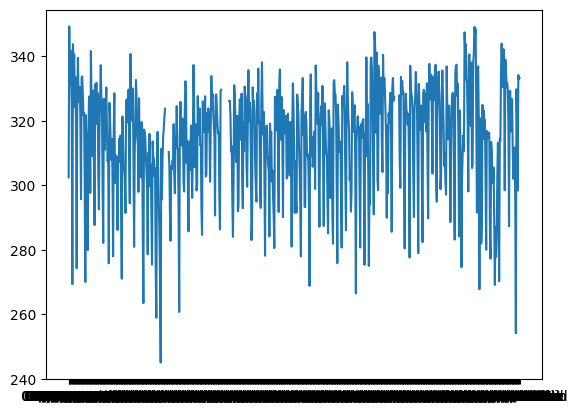

In [7]:
plt.plot(df["Date"], df["CCT"])

In [8]:
def prepare_df_for_lstm(df, n_steps):
    df = dc(df)
    df['Date'] = pd.to_datetime(df['Date'])
    
    df.set_index('Date', inplace=True)
    
    for i in reversed(range(1, n_steps+1)):
        df[f'CCT(t-{i})'] = df['CCT'].shift(i)
    
    df.dropna(inplace=True)
    
    return df

lookback = 7
shifted_df = prepare_df_for_lstm(df, lookback)
shifted_df

/tmp/ipykernel_9085/851480572.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


,CCT,CCT(t-7),CCT(t-6),CCT(t-5),CCT(t-4),CCT(t-3),CCT(t-2),CCT(t-1)
Date,,,,,,,,
2024-01-08,343.75,302.45,349.22,331.07,341.80,334.56,323.18,269.32
2024-01-09,334.94,349.22,331.07,341.80,334.56,323.18,269.32,343.75
2024-01-10,340.56,331.07,341.80,334.56,323.18,269.32,343.75,334.94
2024-01-11,324.22,341.80,334.56,323.18,269.32,343.75,334.94,340.56
2024-01-12,333.50,334.56,323.18,269.32,343.75,334.94,340.56,324.22
...,...,...,...,...,...,...,...,...
2025-12-27,318.87,310.08,301.96,309.27,311.69,295.41,254.13,329.72
2025-12-28,298.36,301.96,309.27,311.69,295.41,254.13,329.72,318.87
2025-12-29,334.15,309.27,311.69,295.41,254.13,329.72,318.87,298.36


In [9]:
device = 'cuda:0' if torch.cuda.is_available else 'cpu'
device

'cuda:0'

In [ ]:
scaler = MinMaxScaler(feature_range=(-1, 1))
normalized_shifted_df = torch.tensor(scaler.fit_transform(shifted_df.to_numpy()), dtype=torch.bfloat16, device=device)

normalized_shifted_df

tensor([[ 0.8984,  0.1021,  1.0000,  ...,  0.7227,  0.5039, -0.5352],
        [ 0.7266,  1.0000,  0.6523,  ...,  0.5039, -0.5352,  0.8984],
        [ 0.8359,  0.6523,  0.8594,  ..., -0.5352,  0.8984,  0.7266],
        ...,
        [ 0.7109,  0.2334,  0.2793,  ...,  0.6289,  0.4199,  0.0249],
        [ 0.6875,  0.2793, -0.0330,  ...,  0.4199,  0.0249,  0.7109],
        [ 0.6953, -0.0330, -0.8242,  ...,  0.0249,  0.7109,  0.6875]],
       device='cuda:0', dtype=torch.bfloat16)

In [11]:
X = normalized_shifted_df[:, 1:]
y = normalized_shifted_df[:, 0]

X.shape, y.shape

(torch.Size([679, 7]), torch.Size([679]))

In [12]:
normalized_shifted_df.device

device(type='cuda', index=0)

In [13]:
split_index = int(len(X) * .95)
split_index

645

In [14]:
# need to add dimensions for LSTM
X_train = X[:split_index].reshape(-1, lookback, 1)
X_test = X[split_index:].reshape(-1, lookback, 1)

y_train = y[:split_index].reshape(-1, 1)
y_test = y[split_index:].reshape(-1, 1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([645, 7, 1]),
 torch.Size([34, 7, 1]),
 torch.Size([645, 1]),
 torch.Size([34, 1]))

In [30]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i].to(torch.bfloat16), self.y[i].to(torch.bfloat16)

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [31]:
train_dataset, test_dataset

(<__main__.TimeSeriesDataset at 0x782e8a6d2b70>,
 <__main__.TimeSeriesDataset at 0x782e8a6d08f0>)

In [32]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [33]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)

torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size([16, 7, 1]) torch.Size([16, 1])
torch.Size(

In [42]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(                    # batched first -> batch as first dimension
            input_size, 
            hidden_size, 
            num_stacked_layers, 
            batch_first=True, 
            dtype=torch.bfloat16
        )  
        
        self.fc = nn.Linear(hidden_size, 1, dtype=torch.bfloat16)     # fc to map hidden size to just 1, final value

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, dtype=torch.bfloat16).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, dtype=torch.bfloat16).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM(1, 4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [45]:
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0], batch[1]

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 10 == 9:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [49]:
learning_rate = 0.001
num_epochs = 100
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1
Batch 10, Loss: 0.008
Batch 20, Loss: 0.010
Batch 30, Loss: 0.012
Batch 40, Loss: 0.009

Val Loss: 0.137
***************************************************

Epoch: 2
Batch 10, Loss: 0.010
Batch 20, Loss: 0.011
Batch 30, Loss: 0.010
Batch 40, Loss: 0.008

Val Loss: 0.140
***************************************************

Epoch: 3
Batch 10, Loss: 0.008
Batch 20, Loss: 0.013
Batch 30, Loss: 0.009
Batch 40, Loss: 0.009

Val Loss: 0.138
***************************************************

Epoch: 4
Batch 10, Loss: 0.009
Batch 20, Loss: 0.009
Batch 30, Loss: 0.011
Batch 40, Loss: 0.010

Val Loss: 0.138
***************************************************

Epoch: 5
Batch 10, Loss: 0.010
Batch 20, Loss: 0.010
Batch 30, Loss: 0.009
Batch 40, Loss: 0.010

Val Loss: 0.138
***************************************************

Epoch: 6
Batch 10, Loss: 0.010
Batch 20, Loss: 0.010
Batch 30, Loss: 0.009
Batch 40, Loss: 0.011

Val Loss: 0.138
***************************************************

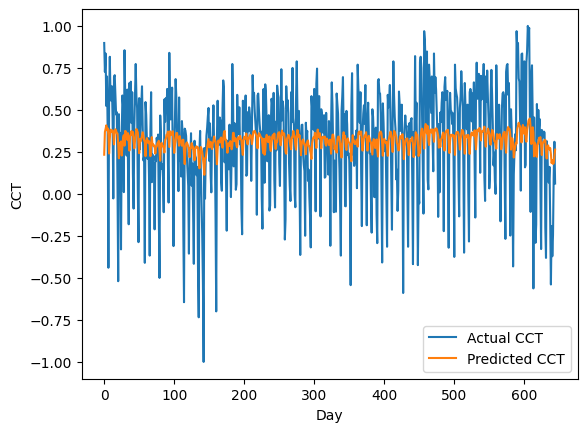

In [57]:
with torch.no_grad():
    predicted = model(X_train).to(torch.float32).cpu().numpy()

plt.plot(y_train.to(torch.float32).cpu().numpy(), label='Actual CCT')
plt.plot(predicted, label='Predicted CCT')
plt.xlabel('Day')
plt.ylabel('CCT')
plt.legend()
plt.show()
